In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('../data')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv(DATA_DIR / 'olist_clean.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

df['freight_ratio'] = df['freight_value'] / df['price']
print(f"Loaded: {df.shape}")

Loaded: (110645, 23)


In [2]:
# INSIGHT 1: IMPACT OF LATE DELIVERY ON REVENUE
late_revenue = df.groupby('is_late').agg(
    orders=('order_id', 'nunique'),
    avg_review=('review_score', 'mean'),
    total_revenue=('price', 'sum'),
    avg_order_value=('price', 'mean')
).round(2)

late_revenue.index = ['On-time / Early', 'Late']
print(late_revenue)

                 orders  avg_review  total_revenue  avg_order_value
On-time / Early   89773        4.21    12269949.29           118.72
Late               6531        2.26      989481.67           135.73


                   orders  late_rate  avg_review
processing_bucket                               
0-1                 24010      0.047       4.181
1-2                 16299      0.058       4.120
2-3                 12005      0.061       4.075
3-5                 13407      0.073       4.009
5-10                 8529      0.111       3.838
10+                  3074      0.303       3.227


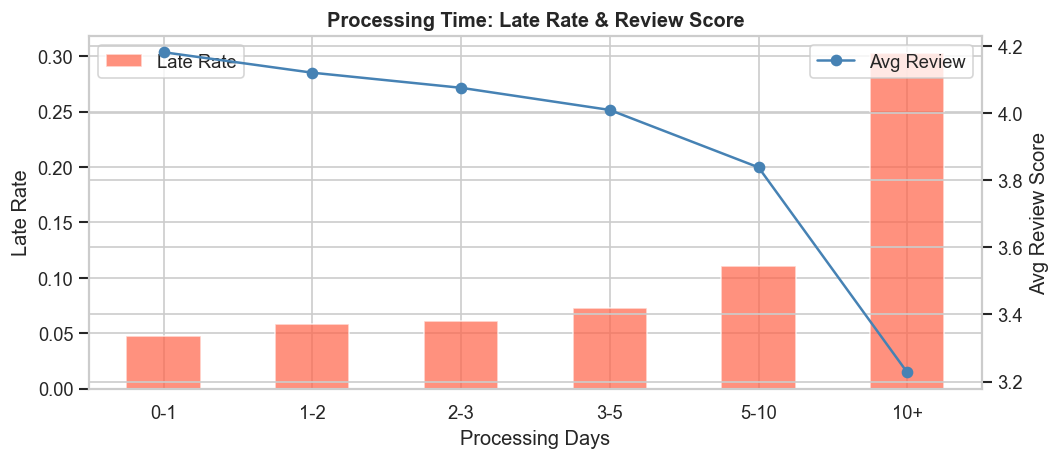

In [3]:
# INSIGHT 2: PROCESSING TIME THRESHOLD ANALYSIS
df['processing_bucket'] = pd.cut(df['processing_days'],
                                  bins=[0,1,2,3,5,10,125],
                                  labels=['0-1','1-2','2-3','3-5','5-10','10+'])

threshold_stats = df.groupby('processing_bucket', observed=True).agg(
    orders=('order_id', 'nunique'),
    late_rate=('is_late', 'mean'),
    avg_review=('review_score', 'mean')
).round(3)

print(threshold_stats)

fig, ax = plt.subplots(figsize=(9, 4))
ax2 = ax.twinx()

threshold_stats['late_rate'].plot(kind='bar', ax=ax, color='tomato', 
                                   alpha=0.7, label='Late Rate')
threshold_stats['avg_review'].plot(ax=ax2, color='steelblue', 
                                    marker='o', label='Avg Review')

ax.set_title('Processing Time: Late Rate & Review Score', fontweight='bold')
ax.set_xlabel('Processing Days')
ax.set_ylabel('Late Rate')
ax2.set_ylabel('Avg Review Score')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../visuals/11_processing_threshold.png', dpi=120)
plt.show()

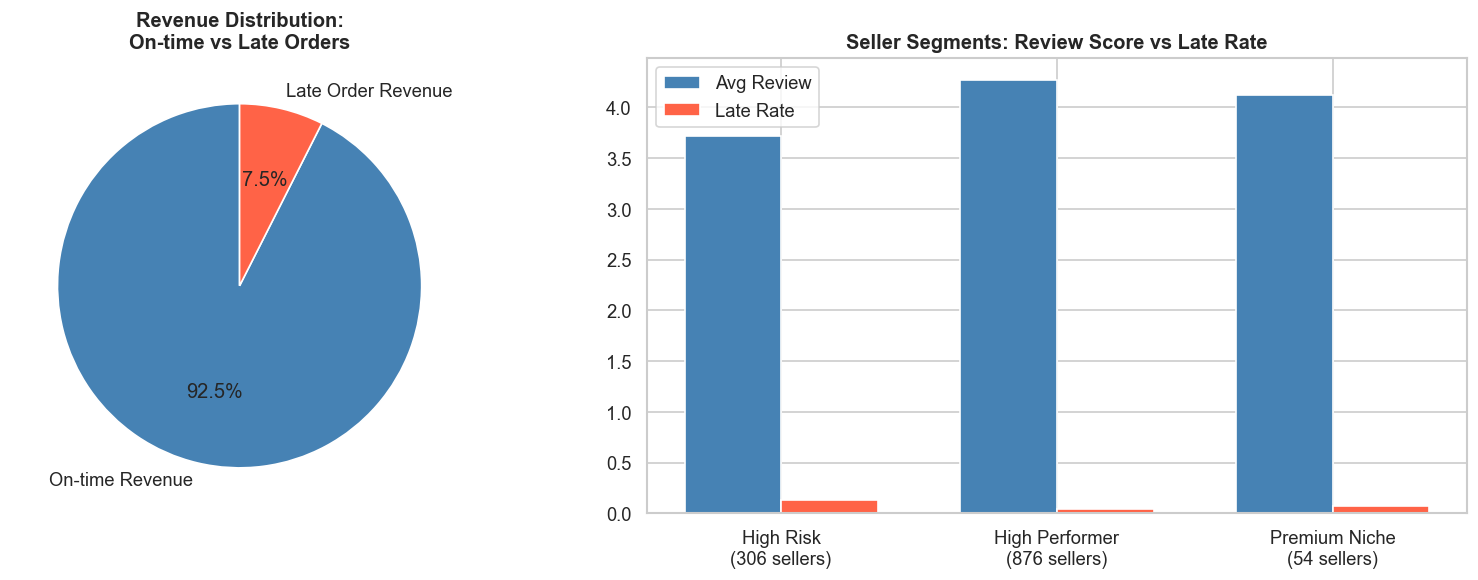

In [4]:
# INSIGHT 3: STRATEGIC RECOMMENDATIONS SUMMARY
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue at risk from late orders
labels = ['On-time Revenue', 'Late Order Revenue']
values = [12269949.29, 989481.67]
colors = ['steelblue', 'tomato']
axes[0].pie(values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Revenue Distribution:\nOn-time vs Late Orders', fontweight='bold')

# Review score by cluster
cluster_labels = ['High Risk\n(306 sellers)', 'High Performer\n(876 sellers)', 'Premium Niche\n(54 sellers)']
review_scores = [3.72, 4.27, 4.12]
late_rates = [0.13, 0.04, 0.07]

x = np.arange(len(cluster_labels))
width = 0.35
bars1 = axes[1].bar(x - width/2, review_scores, width, label='Avg Review', color='steelblue')
bars2 = axes[1].bar(x + width/2, late_rates, width, label='Late Rate', color='tomato')
axes[1].set_title('Seller Segments: Review Score vs Late Rate', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cluster_labels)
axes[1].legend()

plt.tight_layout()
plt.savefig('../visuals/12_strategic_summary.png', dpi=120)
plt.show()

In [5]:
# FINAL SUMMARY & RECOMMENDATIONS
print("""
Notebook 05 — Strategic Insights & Recommendations
====================================================

FINDING 1: Late delivery is the single biggest driver of dissatisfaction
  · Late orders average 2.26 review score vs 4.21 for on-time (-1.95 pts)
  · Late orders have higher avg order value (135 BRL vs 118 BRL)
  · Recommendation: Prioritize on-time fulfillment for high-value orders

FINDING 2: Processing time is the key operational lever
  · Orders processed in 0-1 days: 4.7% late rate
  · Orders processed in 10+ days: 30.3% late rate
  · Critical threshold: beyond 5 days, late rate doubles
  · Recommendation: Enforce 3-day processing SLA across all sellers

FINDING 3: 25% of sellers generate disproportionate dissatisfaction
  · High Risk segment (306 sellers): 13% late rate, 3.72 avg review
  · High Performer segment (876 sellers): 4% late rate, 4.27 avg review
  · Recommendation: Targeted intervention on High Risk sellers —
    performance warnings, SLA enforcement, or platform delisting

FINDING 4: Price does not drive satisfaction — operations do
  · Price correlation with review score: 0.003 (negligible)
  · Freight ratio correlation: -0.040
  · Recommendation: D2C brands should invest in operational 
    excellence over pricing strategy to improve customer retention
""")


Notebook 05 — Strategic Insights & Recommendations

FINDING 1: Late delivery is the single biggest driver of dissatisfaction
  · Late orders average 2.26 review score vs 4.21 for on-time (-1.95 pts)
  · Late orders have higher avg order value (135 BRL vs 118 BRL)
  · Recommendation: Prioritize on-time fulfillment for high-value orders

FINDING 2: Processing time is the key operational lever
  · Orders processed in 0-1 days: 4.7% late rate
  · Orders processed in 10+ days: 30.3% late rate
  · Critical threshold: beyond 5 days, late rate doubles
  · Recommendation: Enforce 3-day processing SLA across all sellers

FINDING 3: 25% of sellers generate disproportionate dissatisfaction
  · High Risk segment (306 sellers): 13% late rate, 3.72 avg review
  · High Performer segment (876 sellers): 4% late rate, 4.27 avg review
  · Recommendation: Targeted intervention on High Risk sellers —
    performance warnings, SLA enforcement, or platform delisting

FINDING 4: Price does not drive satisfact